# **Automated Detection of Malaria in Blood Smear Images Using Deep Learning**

**Dataset:** [Blood Smear Images Dataset for AI-based Malaria Parasite Prediction](https://data.mendeley.com/datasets/6zpxnhjxzz/1)

## **Environment Setup & Dataset Acquisition**

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
100% 675M/675M [00:10<00:00, 70.7MB/s]



In [5]:
!unzip -q cell-images-for-detecting-malaria.zip -d malaria_data

## **Importing Libraries**

In [6]:
import os
import shutil
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D, Dropout, Flatten, Input,
                                     BatchNormalization, MaxPooling2D, Conv2D)
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, f1_score, classification_report)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## **Dataset Organization**

In [7]:
import os
import shutil

# Define paths
source_dir = 'malaria_data/cell_images'
dest_dir = 'malaria_data'

print("Starting dataset reorganization...")

# Move Parasitized and Uninfected folders
for folder_name in ['Parasitized', 'Uninfected']:
    src_path = os.path.join(source_dir, folder_name)
    dst_path = os.path.join(dest_dir, folder_name)

    if os.path.exists(src_path):
        if not os.path.exists(dst_path):
            shutil.move(src_path, dst_path)
            print(f"Moved '{src_path}' to '{dst_path}'")
        else:
            print(f"Destination '{dst_path}' already exists. Skipping move for '{src_path}'.")
    else:
        print(f"Warning: Source '{src_path}' not found. Skipping move.")

# Explicitly remove the original 'cell_images' directory (which contains duplicates).
# The goal is to flatten the structure, so this intermediate directory should be removed.
if os.path.exists(source_dir):
    print(f"Cleaning up redundant directory '{source_dir}'...")
    try:
        shutil.rmtree(source_dir)
        print(f"Removed '{source_dir}' successfully.")
    except OSError as e:
        print(f"Error removing directory '{source_dir}': {e}")
else:
    print(f"Directory '{source_dir}' already removed or never existed.")

# Function to count images in a directory and its subdirectories
def count_images(base_path):
    total_images = 0
    for root, _, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                total_images += 1
    return total_images

# Get total image count from the reorganized 'malaria_data' directory
total_image_count = count_images(dest_dir)
print(f"\nTotal images in '{dest_dir}': {total_image_count}")

# Verify the new structure
print("\nNew directory structure under 'malaria_data':")
for item in os.listdir(dest_dir):
    item_path = os.path.join(dest_dir, item)
    if os.path.isdir(item_path):
        count = count_images(item_path)
        print(f"  - {item}/: {count} images")

print("\nDataset reorganization complete.")


Starting dataset reorganization...
Moved 'malaria_data/cell_images/Parasitized' to 'malaria_data/Parasitized'
Moved 'malaria_data/cell_images/Uninfected' to 'malaria_data/Uninfected'
Cleaning up redundant directory 'malaria_data/cell_images'...
Removed 'malaria_data/cell_images' successfully.

Total images in 'malaria_data': 27558

New directory structure under 'malaria_data':
  - Parasitized/: 13779 images
  - Uninfected/: 13779 images

Dataset reorganization complete.


In [8]:
def check_dataset_structure(folder_path):
    classes = sorted([d for d in os.listdir(folder_path)
                     if os.path.isdir(os.path.join(folder_path, d))])

    print("Dataset structure:")
    for class_name in classes:
        class_path = os.path.join(folder_path, class_name)
        num_images = len([f for f in os.listdir(class_path)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"  {class_name}: {num_images} images")

    return classes

classes = check_dataset_structure('malaria_data')

Dataset structure:
  Parasitized: 13779 images
  Uninfected: 13779 images


## **Train / Validation / Test Split**

In [9]:
# Source folders from reorganised dataset
parasitized_folder = 'malaria_data/Parasitized'
uninfected_folder  = 'malaria_data/Uninfected'

output_dir = 'Dataset'
for split in ['train', 'val', 'test']:
    for cls in ['parasitized', 'uninfected']:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

def split_and_copy(img_list, cls_name, src_folder):
    train_imgs, temp = train_test_split(img_list, test_size=0.30, random_state=42)
    val_imgs, test_imgs = train_test_split(temp, test_size=0.50, random_state=42)

    for split_name, split_imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
        dest = os.path.join(output_dir, split_name, cls_name)
        for img_name in split_imgs:
            src = os.path.join(src_folder, img_name)
            shutil.copy2(src, os.path.join(dest, img_name))
    print(f"  {cls_name}: train={len(train_imgs)}, val={len(val_imgs)}, test={len(test_imgs)}")

print("Splitting Parasitized images ...")
parasitized_imgs = [f for f in os.listdir(parasitized_folder)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
split_and_copy(parasitized_imgs, 'parasitized', parasitized_folder)

print("Splitting Uninfected images ...")
uninfected_imgs = [f for f in os.listdir(uninfected_folder)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
split_and_copy(uninfected_imgs, 'uninfected', uninfected_folder)

print("\nDataset split complete.")


Splitting Parasitized images ...
  parasitized: train=9645, val=2067, test=2067
Splitting Uninfected images ...
  uninfected: train=9645, val=2067, test=2067

Dataset split complete.


#### Sample Images from Each Class

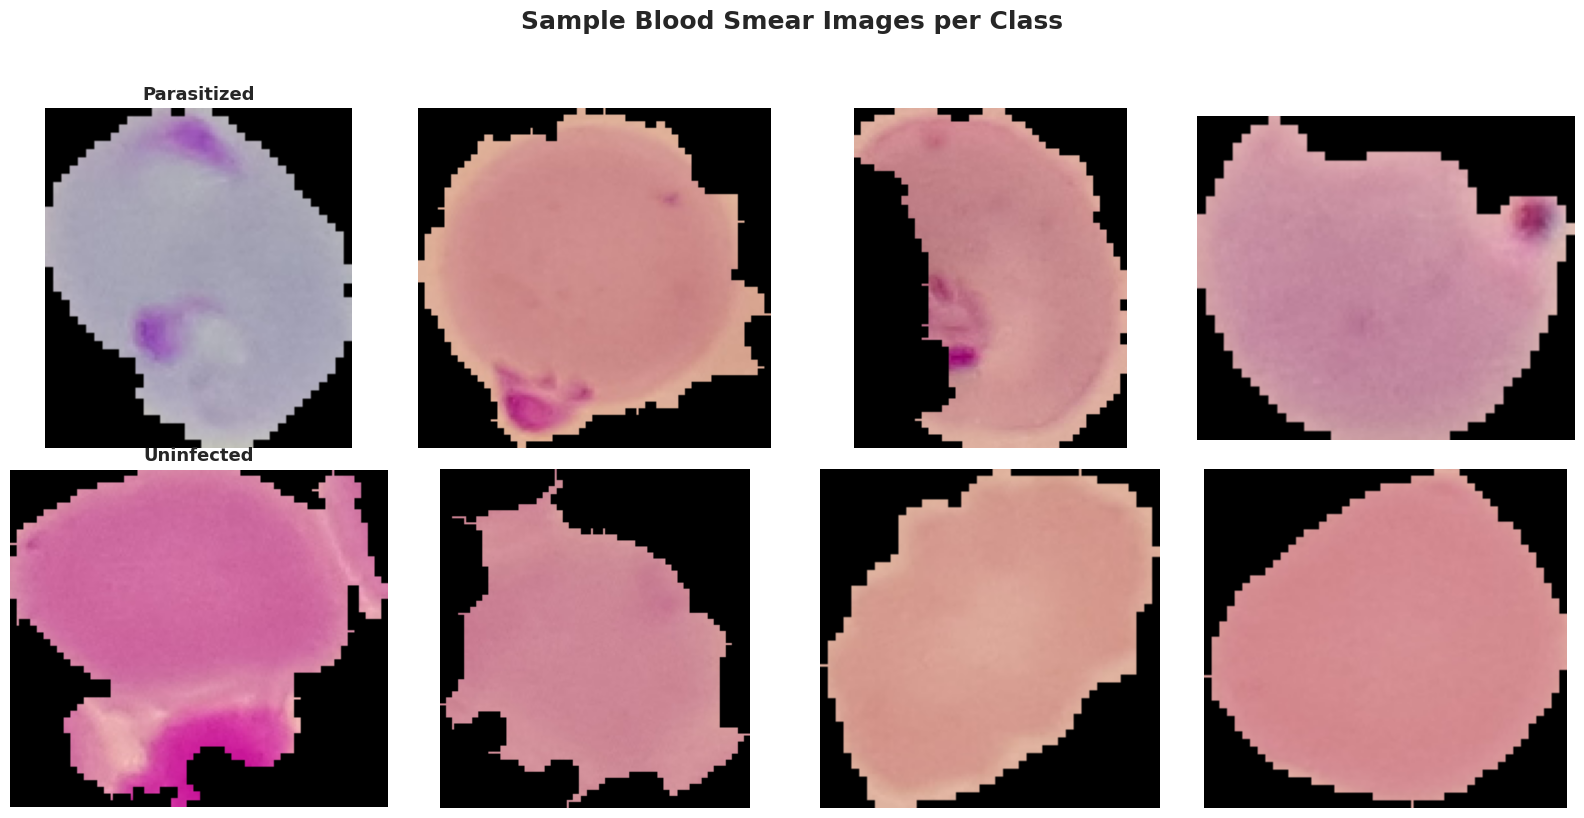

In [10]:
def sample_images_display(folder_path, num_images=4):
    classes = sorted([d for d in os.listdir(folder_path)
                      if os.path.isdir(os.path.join(folder_path, d))])
    fig, axes = plt.subplots(len(classes), num_images,
                             figsize=(4 * num_images, 4 * len(classes)))
    fig.suptitle('Sample Blood Smear Images per Class', fontsize=18,
                 fontweight='bold', y=1.02)

    for i, class_name in enumerate(classes):
        class_path = os.path.join(folder_path, class_name)
        files = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        selected = random.sample(files, min(num_images, len(files)))
        for j, img_name in enumerate(selected):
            img = Image.open(os.path.join(class_path, img_name))
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(class_name.capitalize(), fontsize=13,
                                     fontweight='bold')
    plt.tight_layout()
    plt.show()

sample_images_display('Dataset/train')


## **Exploratory Data Analysis (EDA)**

#### **Class Distribution Across Splits**

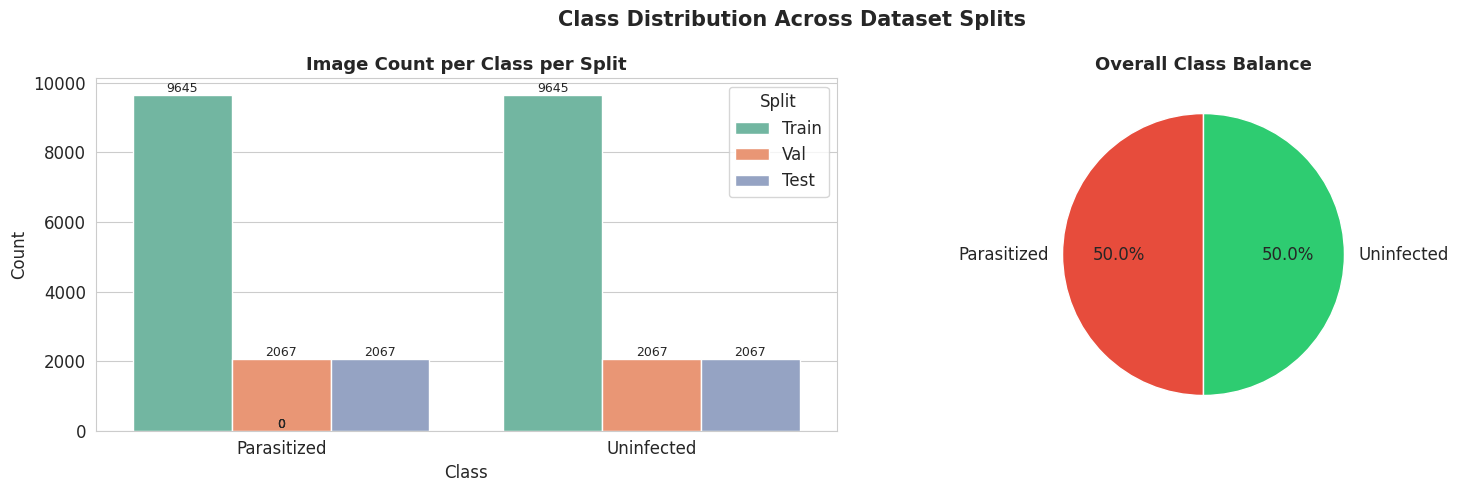

In [11]:
split_data = []
for split in ['train', 'val', 'test']:
    split_path = os.path.join('Dataset', split)
    for c in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, c)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            split_data.append({'Split': split.capitalize(),
                               'Class': c.capitalize(), 'Count': count})

split_df = pd.DataFrame(split_data)
model_colors = ['#3498db', '#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Class Distribution Across Dataset Splits', fontsize=15, fontweight='bold')

sns.barplot(data=split_df, x='Class', y='Count', hue='Split',
            palette='Set2', ax=axes[0])
axes[0].set_title('Image Count per Class per Split', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(title='Split')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

total_per_class = split_df.groupby('Class')['Count'].sum()
axes[1].pie(total_per_class, labels=total_per_class.index,
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Overall Class Balance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


#### **Image Dimension Analysis**

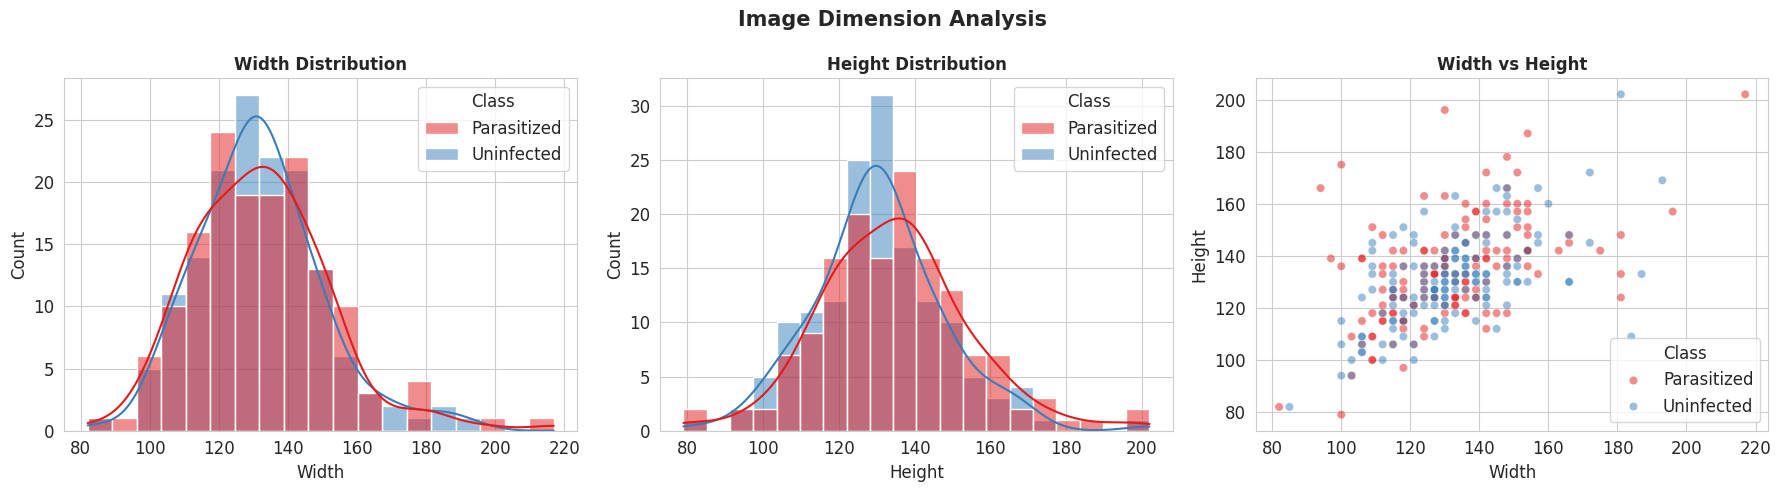

In [12]:
widths, heights, aspect_ratios, img_classes = [], [], [], []
train_path_eda = 'Dataset/train'

for class_name in sorted(os.listdir(train_path_eda)):
    class_path = os.path.join(train_path_eda, class_name)
    if not os.path.isdir(class_path):
        continue
    sample_files = os.listdir(class_path)
    for img_name in random.sample(sample_files, min(150, len(sample_files))):
        try:
            img = Image.open(os.path.join(class_path, img_name))
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
            img_classes.append(class_name.capitalize())
        except Exception:
            continue

dim_df = pd.DataFrame({'Width': widths, 'Height': heights,
                       'Aspect Ratio': aspect_ratios, 'Class': img_classes})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Image Dimension Analysis', fontsize=15, fontweight='bold')

sns.histplot(data=dim_df, x='Width', hue='Class', kde=True,
             palette='Set1', ax=axes[0])
axes[0].set_title('Width Distribution', fontsize=12, fontweight='bold')

sns.histplot(data=dim_df, x='Height', hue='Class', kde=True,
             palette='Set1', ax=axes[1])
axes[1].set_title('Height Distribution', fontsize=12, fontweight='bold')

sns.scatterplot(data=dim_df, x='Width', y='Height', hue='Class',
                alpha=0.5, palette='Set1', ax=axes[2])
axes[2].set_title('Width vs Height', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


#### **Mean Pixel Intensity per Class**

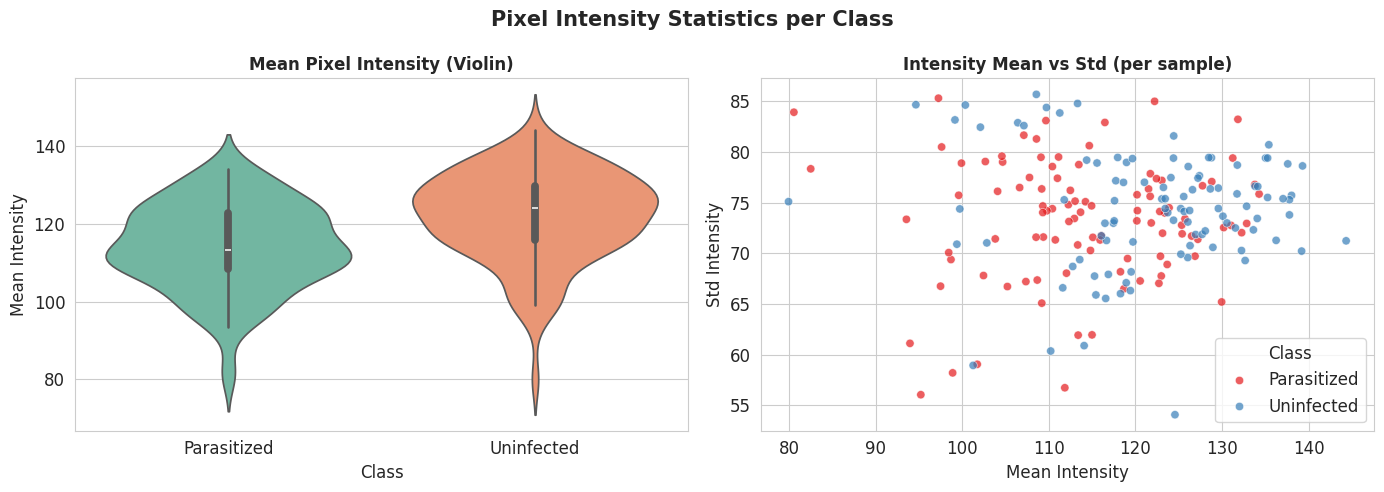

In [13]:
intensity_data = []

for class_name in sorted(os.listdir(train_path_eda)):
    class_path = os.path.join(train_path_eda, class_name)
    if not os.path.isdir(class_path):
        continue
    sample_files = os.listdir(class_path)
    for img_name in random.sample(sample_files, min(100, len(sample_files))):
        try:
            img = Image.open(os.path.join(class_path, img_name)).convert('L')
            arr = np.array(img)
            intensity_data.append({'Class': class_name.capitalize(),
                                   'Mean Intensity': arr.mean(),
                                   'Std Intensity': arr.std()})
        except Exception:
            continue

intensity_df = pd.DataFrame(intensity_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pixel Intensity Statistics per Class', fontsize=15, fontweight='bold')

sns.violinplot(data=intensity_df, x='Class', y='Mean Intensity',
               palette='Set2', ax=axes[0], inner='box')
axes[0].set_title('Mean Pixel Intensity (Violin)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Mean Intensity')

sns.scatterplot(data=intensity_df, x='Mean Intensity', y='Std Intensity',
                hue='Class', palette='Set1', alpha=0.7, ax=axes[1])
axes[1].set_title('Intensity Mean vs Std (per sample)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


#### **RGB Channel Distribution by Class**

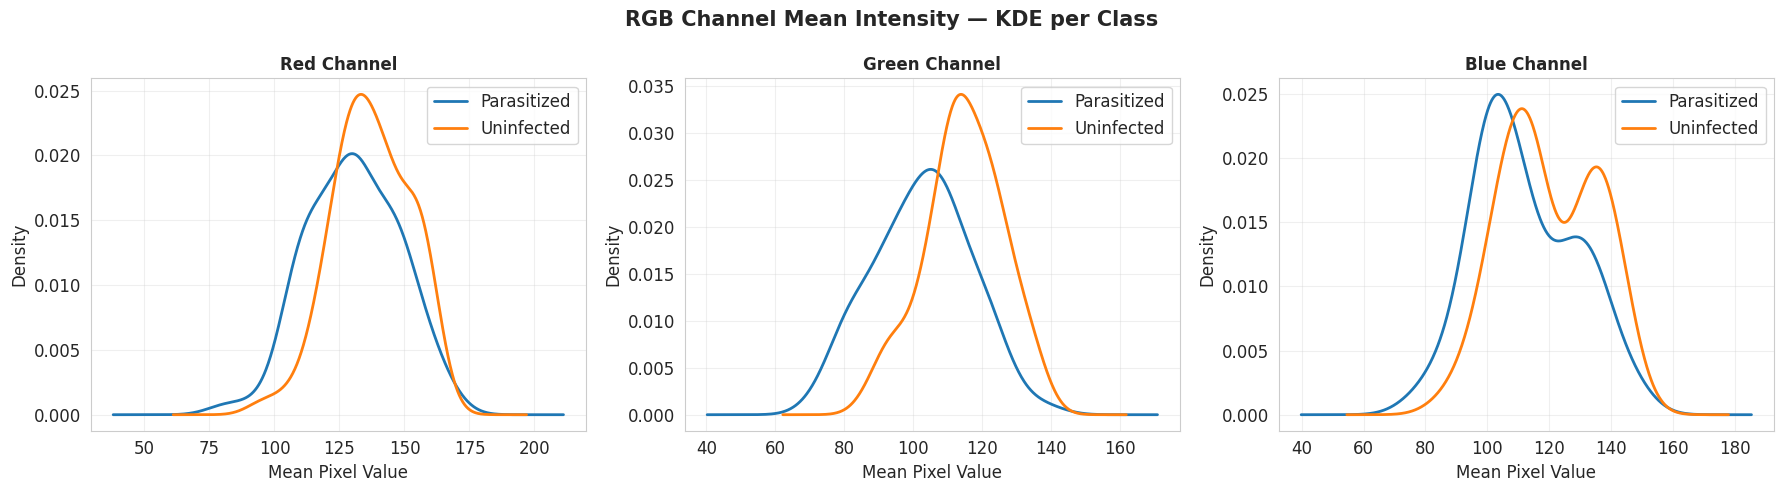

In [14]:
channel_data = []

for class_name in sorted(os.listdir(train_path_eda)):
    class_path = os.path.join(train_path_eda, class_name)
    if not os.path.isdir(class_path):
        continue
    sample_files = os.listdir(class_path)
    for img_name in random.sample(sample_files, min(80, len(sample_files))):
        try:
            img = Image.open(os.path.join(class_path, img_name)).convert('RGB')
            arr = np.array(img)
            channel_data.append({'Class': class_name.capitalize(),
                                 'Red':   arr[:, :, 0].mean(),
                                 'Green': arr[:, :, 1].mean(),
                                 'Blue':  arr[:, :, 2].mean()})
        except Exception:
            continue

channel_df = pd.DataFrame(channel_data)
ch_colors = ['#e74c3c', '#2ecc71', '#3498db']
channel_names = ['Red', 'Green', 'Blue']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RGB Channel Mean Intensity — KDE per Class', fontsize=15, fontweight='bold')

for ax, ch, color in zip(axes, channel_names, ch_colors):
    for cls in channel_df['Class'].unique():
        subset = channel_df[channel_df['Class'] == cls][ch]
        subset.plot.kde(ax=ax, label=cls, linewidth=2)
    ax.set_title(f'{ch} Channel', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Pixel Value')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## **Data Generator Setup**

In [15]:
np.random.seed(42)
tf.random.set_seed(42)

train_path = 'Dataset/train'
val_path   = 'Dataset/val'
test_path  = 'Dataset/test'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True)

print("\nLoading Validation Data:")
val_generator = val_test_datagen.flow_from_directory(
    val_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False)

print("\nLoading Test Data:")
test_generator = val_test_datagen.flow_from_directory(
    test_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False)

CLASS_NAMES = list(train_generator.class_indices.keys())
print(f"\nClass indices: {train_generator.class_indices}")
print(f"Class names  : {CLASS_NAMES}")


Loading Training Data:
Found 19290 images belonging to 2 classes.

Loading Validation Data:
Found 4134 images belonging to 2 classes.

Loading Test Data:
Found 4134 images belonging to 2 classes.

Class indices: {'parasitized': 0, 'uninfected': 1}
Class names  : ['parasitized', 'uninfected']


## **Curve Plot Functions**

In [16]:
def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'{model_name} — Training Curves', fontsize=16, fontweight='bold')

    ep = range(1, len(history.history['accuracy']) + 1)

    axes[0].plot(ep, history.history['accuracy'],     'o-', label='Train Acc',
                 color='#2ecc71', linewidth=2)
    axes[0].plot(ep, history.history['val_accuracy'], 's--', label='Val Acc',
                 color='#e74c3c', linewidth=2)
    axes[0].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, history.history['loss'],     'o-', label='Train Loss',
                 color='#3498db', linewidth=2)
    axes[1].plot(ep, history.history['val_loss'], 's--', label='Val Loss',
                 color='#e67e22', linewidth=2)
    axes[1].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, model_name, gen):
    gen.reset()
    y_prob = model.predict(gen, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)
    y_true = gen.classes

    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average='binary', zero_division=0)
    rec   = recall_score(y_true, y_pred, average='binary', zero_division=0)
    f1    = f1_score(y_true, y_pred, average='binary', zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Results")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"{'='*50}\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print()

    # Per-class metrics bar chart
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    metrics_data = {cls: [report[cls]['precision'], report[cls]['recall'], report[cls]['f1-score']]
                    for cls in CLASS_NAMES}
    metrics_df = pd.DataFrame(metrics_data, index=['Precision', 'Recall', 'F1 Score']).T

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(CLASS_NAMES))
    w = 0.25
    for i, metric in enumerate(['Precision', 'Recall', 'F1 Score']):
        bars = ax.bar(x + i * w, metrics_df[metric], w, label=metric,
                      edgecolor='black', linewidth=0.5)
        for bar, val in zip(bars, metrics_df[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(x + w)
    ax.set_xticklabels(CLASS_NAMES, fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_title(f'{model_name} — Per-Class Metrics', fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1 Score': f1}, y_true, y_prob


## **Model Training & Evaluation**

In [20]:
all_results   = []
all_histories = {}
all_preds     = {}
EPOCHS = 10

#### **Custom CNN**

**Model Architecture**

In [21]:
def build_simple_cnn(input_shape):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        Conv2D(256, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

model1 = build_simple_cnn(IMG_SIZE + (3,))
model1.compile(optimizer=Adam(learning_rate=0.001),
               loss='binary_crossentropy', metrics=['accuracy'])
model1.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,829,057 (37.49 MB)

 Trainable params: 9,827,585 (37.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

**Training**

In [22]:
cb1 = [
    ModelCheckpoint('model1_simple_cnn.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3,
                      min_lr=1e-6, verbose=1)
]

history1 = model1.fit(train_generator, epochs=EPOCHS,
                      validation_data=val_generator, callbacks=cb1)
all_histories['Simple CNN'] = history1


Epoch 1/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.6221 - loss: 0.7894
Epoch 1: val_accuracy improved from None to 0.69836, saving model to model1_simple_cnn.keras

Epoch 1: finished saving model to model1_simple_cnn.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 320s 514ms/step - accuracy: 0.7047 - loss: 0.6239 - val_accuracy: 0.6984 - val_loss: 0.7098 - learning_rate: 0.0010
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.8415 - loss: 0.3895
Epoch 2: val_accuracy improved from 0.69836 to 0.93203, saving model to model1_simple_cnn.keras

Epoch 2: finished saving model to model1_simple_cnn.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 295s 489ms/step - accuracy: 0.8567 - loss: 0.3666 - val_accuracy: 0.9320 - val_loss: 0.2158 - learning_rate: 0.0010
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.8740 - loss: 0.3285
Epoch 3: val_accuracy improved from 0.93203 to 0.94557, saving model to model1_simple_cnn.keras

Epoch 3: finished saving model to model1_s

**Simple CNN — Training Curves**

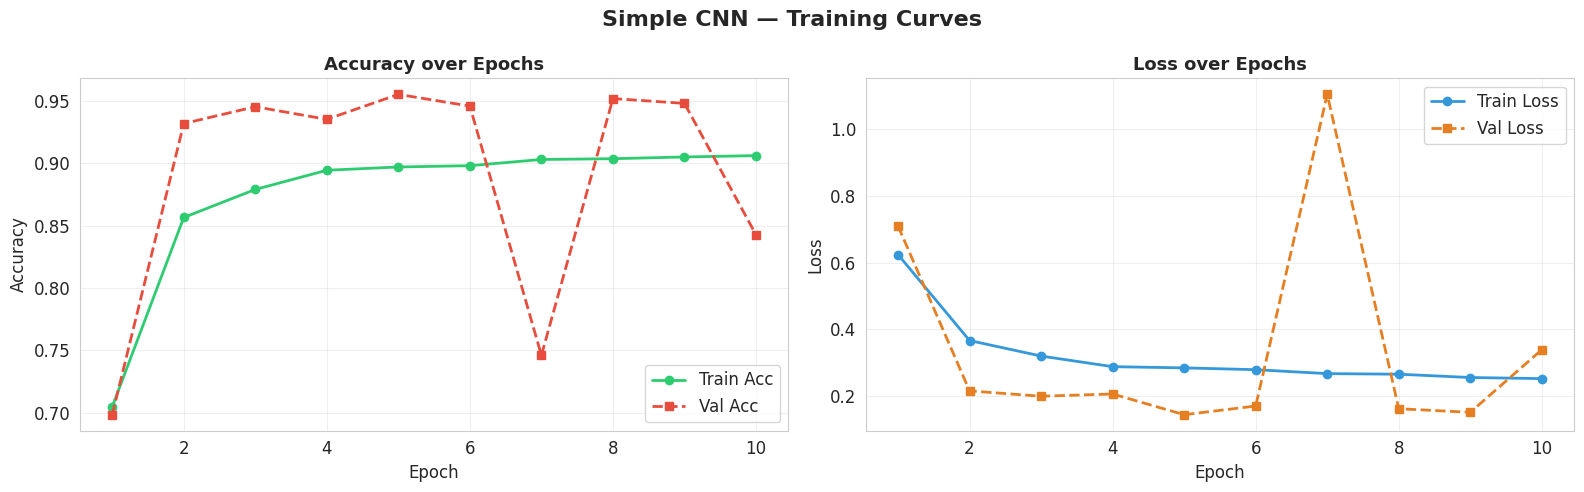

In [23]:
plot_training_curves(history1, 'Simple CNN')

**Simple CNN — Evaluation Metrics**


  Simple CNN — Test Results
  Accuracy  : 0.9507
  Precision : 0.9318
  Recall    : 0.9724
  F1 Score  : 0.9517

              precision    recall  f1-score   support

 parasitized       0.97      0.93      0.95      2067
  uninfected       0.93      0.97      0.95      2067

    accuracy                           0.95      4134
   macro avg       0.95      0.95      0.95      4134
weighted avg       0.95      0.95      0.95      4134



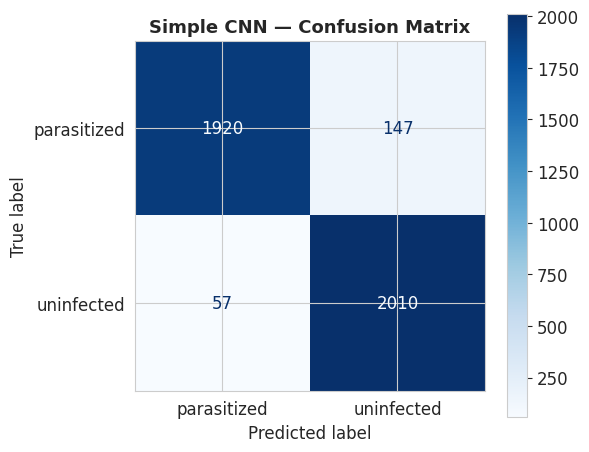

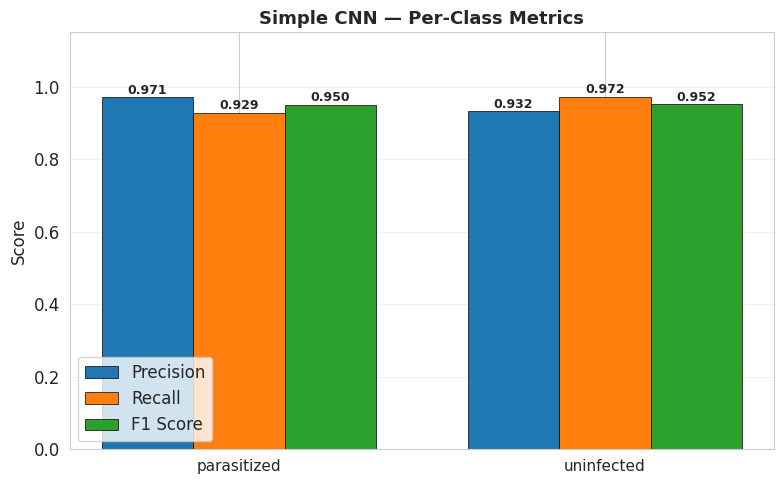

In [24]:
cnn_res, y_true_cnn, y_prob_cnn = evaluate_model(model1, 'Simple CNN', test_generator)
all_results.append(cnn_res)
all_preds['Simple CNN'] = (y_true_cnn, y_prob_cnn)


#### **VGG16 (Transfer Learning)**

**Model Architecture**

In [25]:
def build_vgg16_model(input_shape):
    base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base.layers:
        layer.trainable = 'block5' in layer.name

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)
    return Model(inputs=base.input, outputs=out)

model2 = build_vgg16_model(IMG_SIZE + (3,))
model2.compile(optimizer=Adam(learning_rate=0.0001),
               loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,89

 Total params: 14,880,577 (56.76 MB)

 Trainable params: 7,244,545 (27.64 MB)

 Non-trainable params: 7,636,032 (29.13 MB)

**Training**

In [26]:
cb2 = [
    ModelCheckpoint('model2_vgg16.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3,
                      min_lr=1e-6, verbose=1)
]

history2 = model2.fit(train_generator, epochs=EPOCHS,
                      validation_data=val_generator, callbacks=cb2)
all_histories['VGG16'] = history2


Epoch 1/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.8281 - loss: 0.4173
Epoch 1: val_accuracy improved from None to 0.91824, saving model to model2_vgg16.keras

Epoch 1: finished saving model to model2_vgg16.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 381s 595ms/step - accuracy: 0.8618 - loss: 0.3591 - val_accuracy: 0.9182 - val_loss: 0.2561 - learning_rate: 1.0000e-04
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.8874 - loss: 0.3034
Epoch 2: val_accuracy improved from 0.91824 to 0.93711, saving model to model2_vgg16.keras

Epoch 2: finished saving model to model2_vgg16.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 335s 555ms/step - accuracy: 0.8871 - loss: 0.3050 - val_accuracy: 0.9371 - val_loss: 0.1779 - learning_rate: 1.0000e-04
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.8929 - loss: 0.2906
Epoch 3: val_accuracy improved from 0.93711 to 0.95307, saving model to model2_vgg16.keras

Epoch 3: finished saving model to model2_vgg16.keras
603/60

**VGG16 — Training Curves**

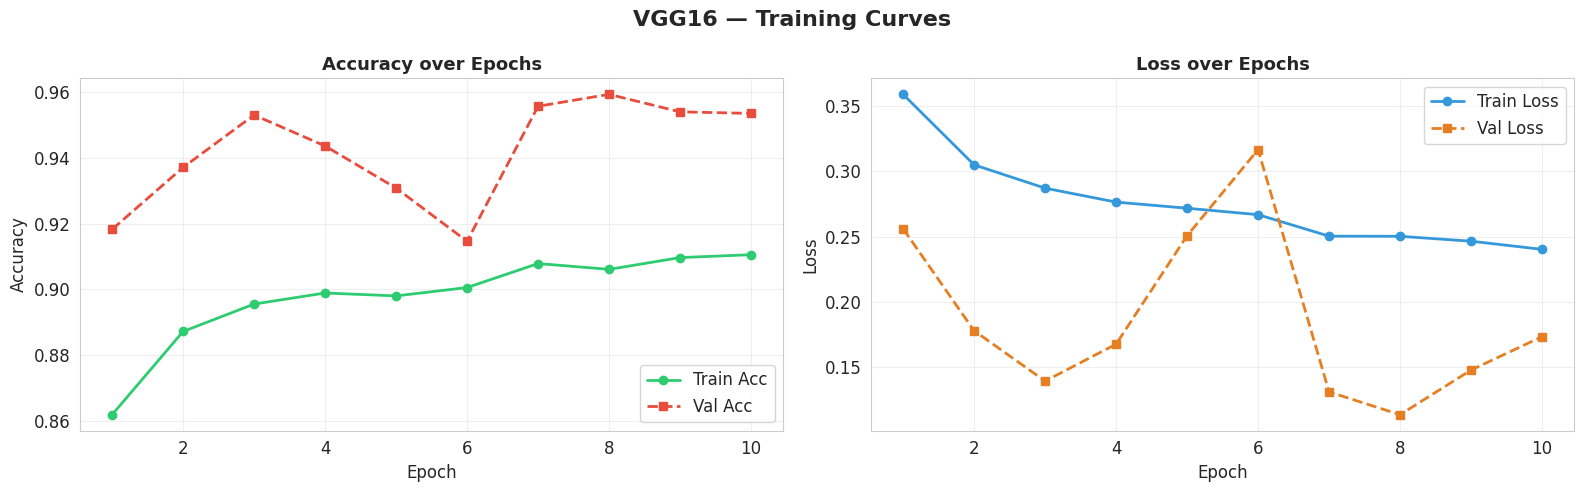

In [27]:
plot_training_curves(history2, 'VGG16')

**VGG16 — Evaluation Metrics**


  VGG16 — Test Results
  Accuracy  : 0.9567
  Precision : 0.9415
  Recall    : 0.9739
  F1 Score  : 0.9574

              precision    recall  f1-score   support

 parasitized       0.97      0.94      0.96      2067
  uninfected       0.94      0.97      0.96      2067

    accuracy                           0.96      4134
   macro avg       0.96      0.96      0.96      4134
weighted avg       0.96      0.96      0.96      4134



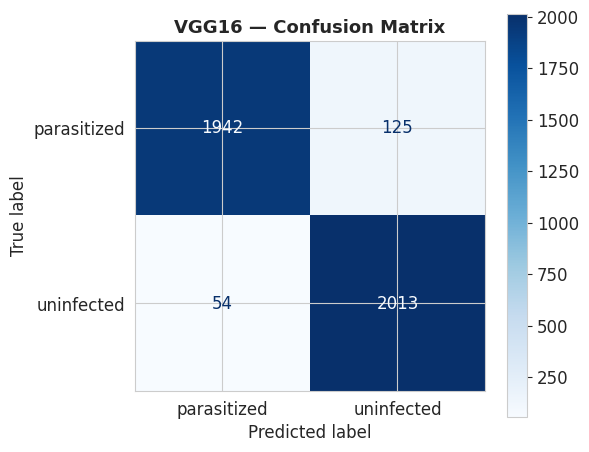

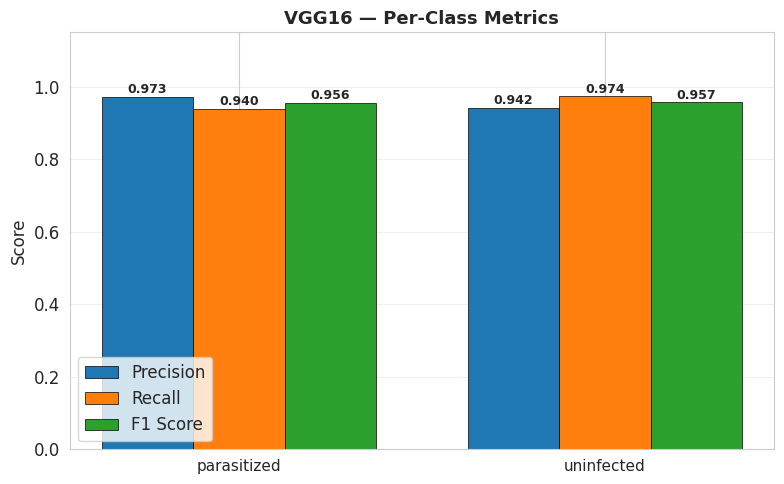

In [28]:
vgg_res, y_true_vgg, y_prob_vgg = evaluate_model(model2, 'VGG16', test_generator)
all_results.append(vgg_res)
all_preds['VGG16'] = (y_true_vgg, y_prob_vgg)


#### **ResNet50 (Transfer Learning)**

**Model Architecture**

In [29]:
def build_resnet50_model(input_shape):
    base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)
    return Model(inputs=base.input, outputs=out)

model3 = build_resnet50_model(IMG_SIZE + (3,))
model3.compile(optimizer=Adam(learning_rate=0.0001),
               loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,146,817 (92.11 MB)

 Trainable params: 15,008,513 (57.25 MB)

 Non-trainable params: 9,138,304 (34.86 MB)

**Training**

In [30]:
cb3 = [
    ModelCheckpoint('model3_resnet50.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3,
                      min_lr=1e-6, verbose=1)
]

history3 = model3.fit(train_generator, epochs=EPOCHS,
                      validation_data=val_generator, callbacks=cb3)
all_histories['ResNet50'] = history3


Epoch 1/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.5139 - loss: 0.8754
Epoch 1: val_accuracy improved from None to 0.50097, saving model to model3_resnet50.keras

Epoch 1: finished saving model to model3_resnet50.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 357s 550ms/step - accuracy: 0.5273 - loss: 0.8275 - val_accuracy: 0.5010 - val_loss: 0.9074 - learning_rate: 1.0000e-04
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.5704 - loss: 0.7507
Epoch 2: val_accuracy did not improve from 0.50097
603/603 ━━━━━━━━━━━━━━━━━━━━ 307s 509ms/step - accuracy: 0.5741 - loss: 0.7509 - val_accuracy: 0.5000 - val_loss: 1.5199 - learning_rate: 1.0000e-04
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.6011 - loss: 0.7180
Epoch 3: val_accuracy improved from 0.50097 to 0.68844, saving model to model3_resnet50.keras

Epoch 3: finished saving model to model3_resnet50.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 305s 506ms/step - accuracy: 0.6033 - loss: 0.7120 - val_acc

**ResNet50 — Training Curves**

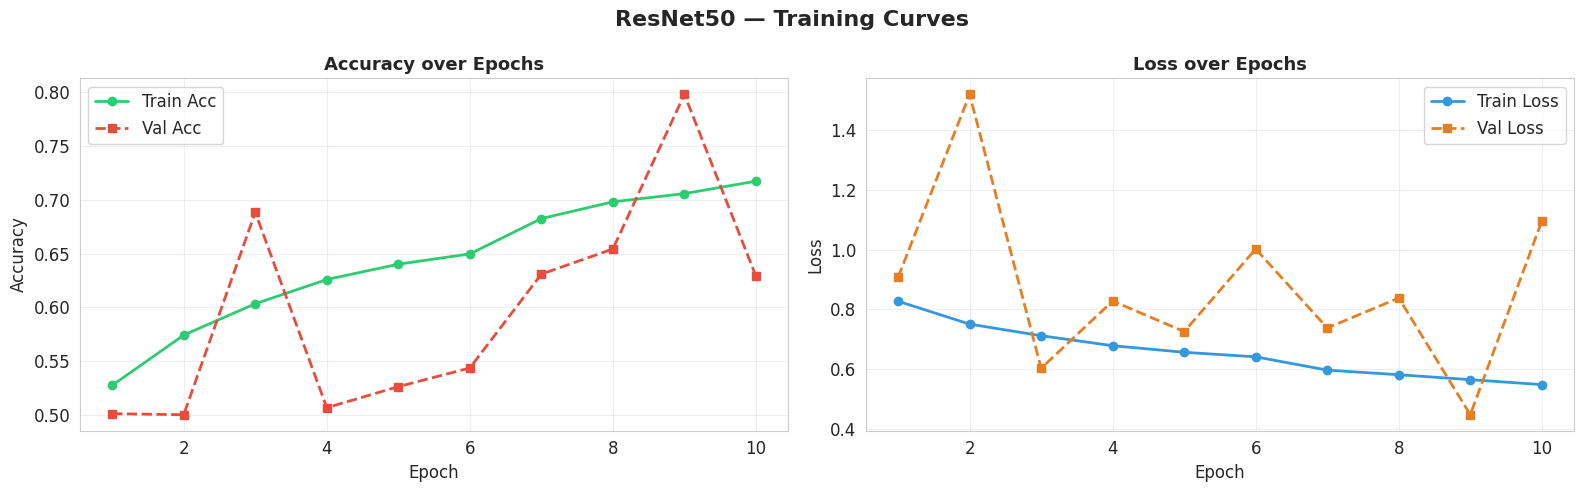

In [31]:
plot_training_curves(history3, 'ResNet50')

**ResNet50 — Evaluation Metrics**


  ResNet50 — Test Results
  Accuracy  : 0.8036
  Precision : 0.8180
  Recall    : 0.7808
  F1 Score  : 0.7990

              precision    recall  f1-score   support

 parasitized       0.79      0.83      0.81      2067
  uninfected       0.82      0.78      0.80      2067

    accuracy                           0.80      4134
   macro avg       0.80      0.80      0.80      4134
weighted avg       0.80      0.80      0.80      4134



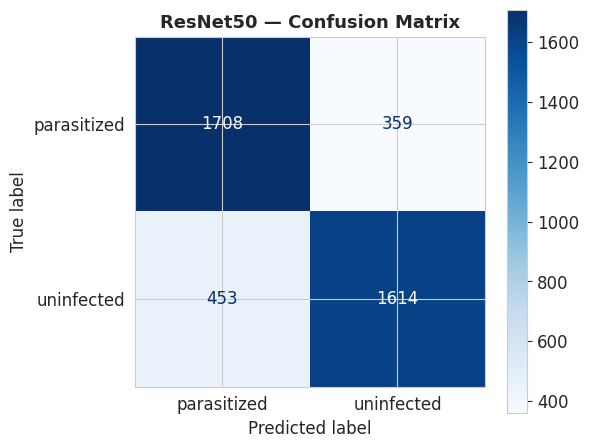

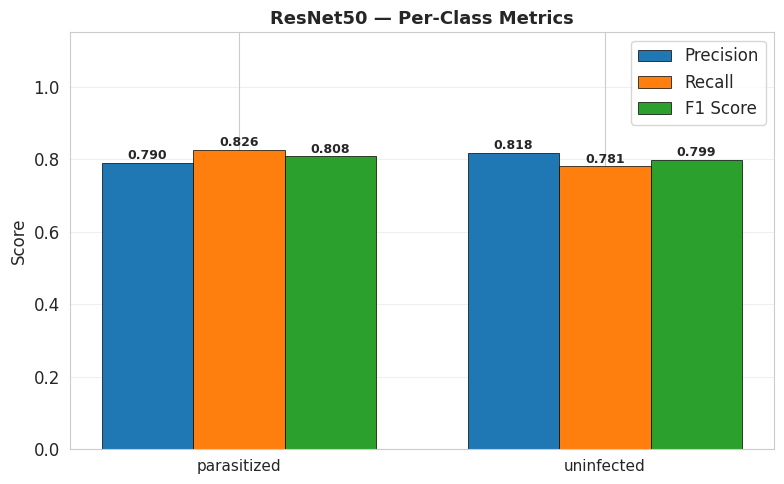

In [32]:
res50_res, y_true_res, y_prob_res = evaluate_model(model3, 'ResNet50', test_generator)
all_results.append(res50_res)
all_preds['ResNet50'] = (y_true_res, y_prob_res)


## **Overall Model Comparison**

In [ ]:
results_df = pd.DataFrame(all_results).set_index('Model')
results_df.style.format('{:.4f}').background_gradient(cmap='YlGn', axis=0)


In [49]:
results_df

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Simple CNN,0.950653,0.931850,0.972424,0.951705
VGG16,0.956701,0.941534,0.973875,0.957432
ResNet50,0.803580,0.818044,0.780842,0.799010


#### **Accuracy Comparison**

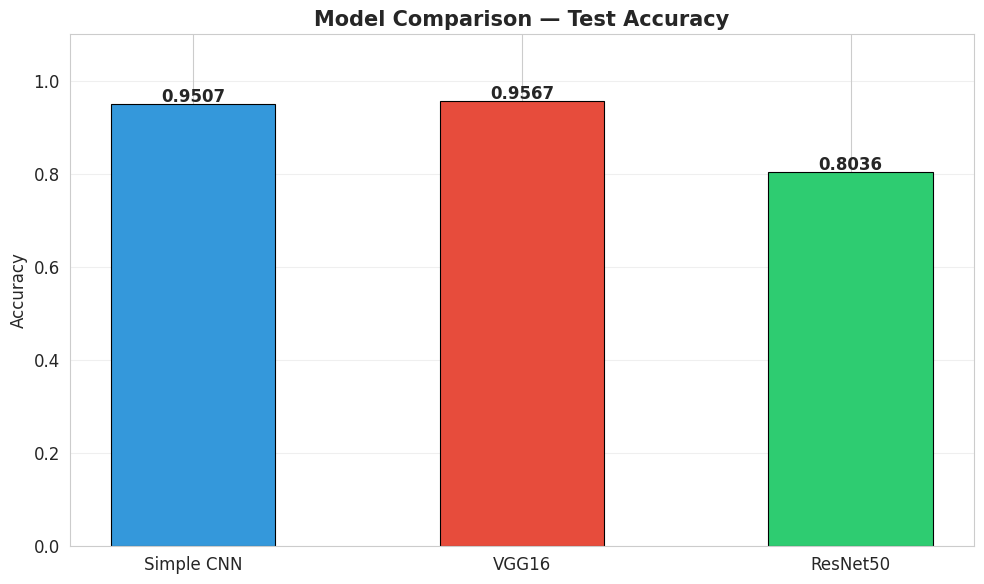

In [34]:
model_colors = ['#3498db', '#e74c3c', '#2ecc71']
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(results_df.index, results_df['Accuracy'], color=model_colors,
              edgecolor='black', linewidth=0.8, width=0.5)
for bar, val in zip(bars, results_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison — Test Accuracy', fontsize=15, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#### **Precision Comparison**

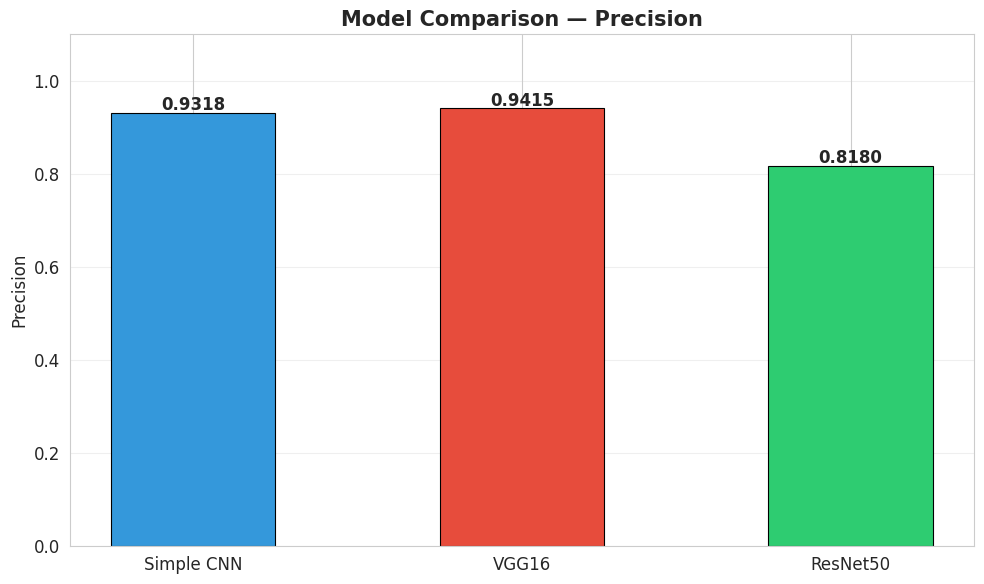

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(results_df.index, results_df['Precision'], color=model_colors,
              edgecolor='black', linewidth=0.8, width=0.5)
for bar, val in zip(bars, results_df['Precision']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison — Precision', fontsize=15, fontweight='bold')
ax.set_ylabel('Precision')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#### **Recall Comparison**

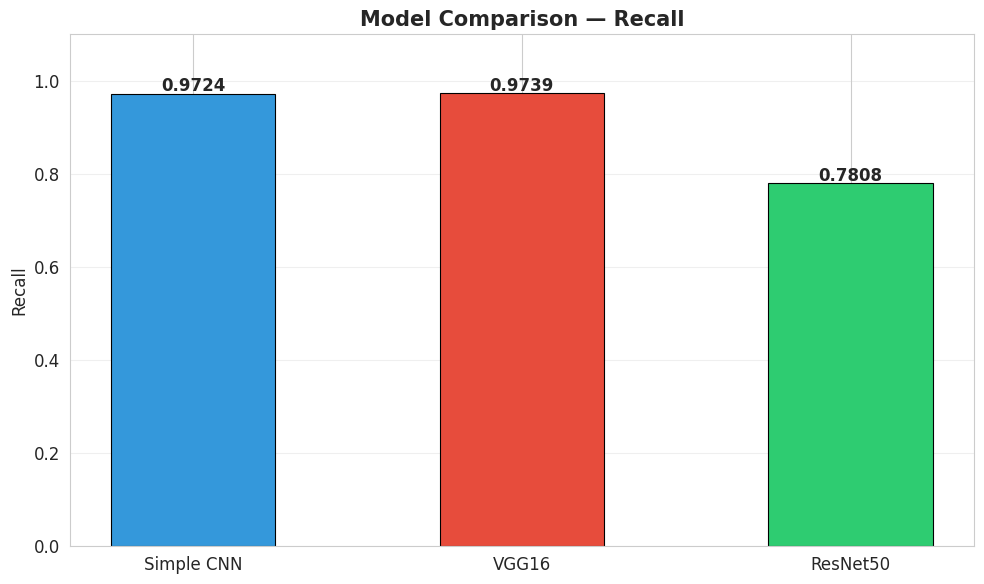

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(results_df.index, results_df['Recall'], color=model_colors,
              edgecolor='black', linewidth=0.8, width=0.5)
for bar, val in zip(bars, results_df['Recall']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison — Recall', fontsize=15, fontweight='bold')
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#### **F1 Score Comparison**

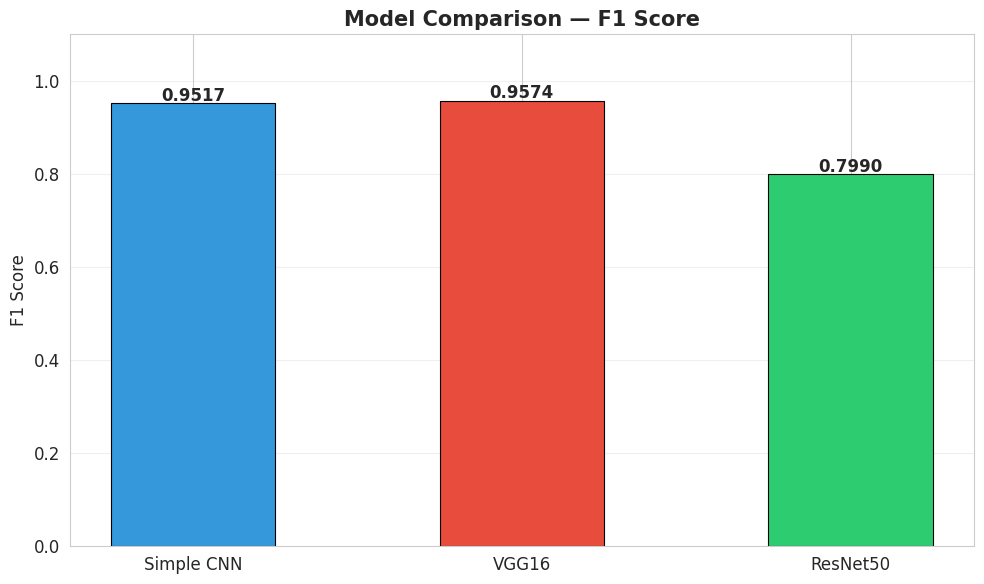

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(results_df.index, results_df['F1 Score'], color=model_colors,
              edgecolor='black', linewidth=0.8, width=0.5)
for bar, val in zip(bars, results_df['F1 Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison — F1 Score', fontsize=15, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#### **Consolidated Metrics — Grouped Bar Chart**

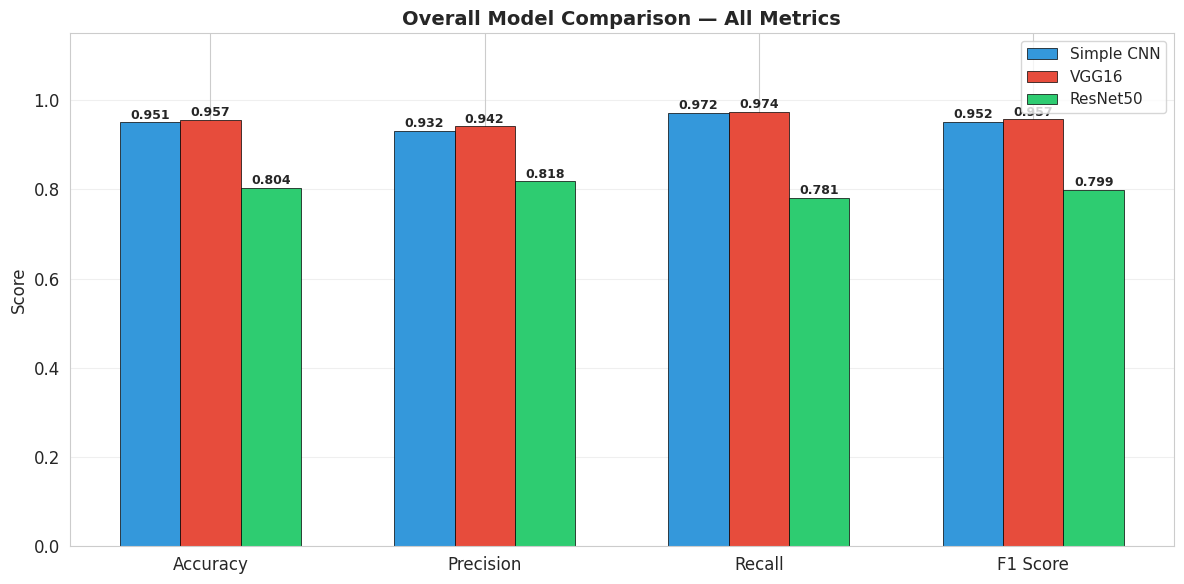

In [38]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names = results_df.index.tolist()
x = np.arange(len(metrics))
width = 0.22

fig, ax = plt.subplots(figsize=(12, 6))
for i, m_name in enumerate(model_names):
    vals = [results_df.loc[m_name, met] for met in metrics]
    bars = ax.bar(x + i * width, vals, width, label=m_name,
                  color=model_colors[i], edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Overall Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#### **Training Convergence Comparison**

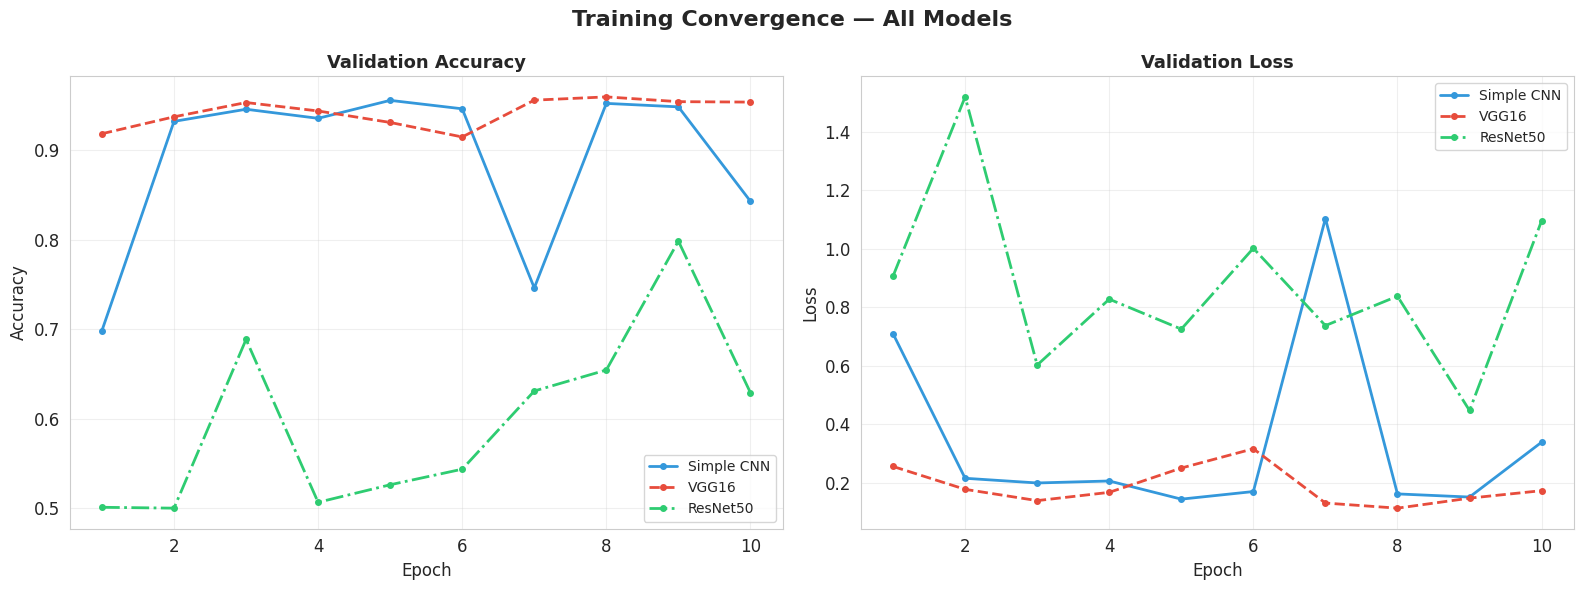

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Training Convergence — All Models', fontsize=16, fontweight='bold')
line_styles = ['-', '--', '-.']

for idx, (name, hist) in enumerate(all_histories.items()):
    ep = range(1, len(hist.history['val_accuracy']) + 1)
    axes[0].plot(ep, hist.history['val_accuracy'], line_styles[idx],
                 label=name, color=model_colors[idx], linewidth=2,
                 marker='o', markersize=4)
    axes[1].plot(ep, hist.history['val_loss'], line_styles[idx],
                 label=name, color=model_colors[idx], linewidth=2,
                 marker='o', markersize=4)

for ax, title, ylabel in zip(axes,
    ['Validation Accuracy', 'Validation Loss'],
    ['Accuracy', 'Loss']):
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### **ROC Curves**

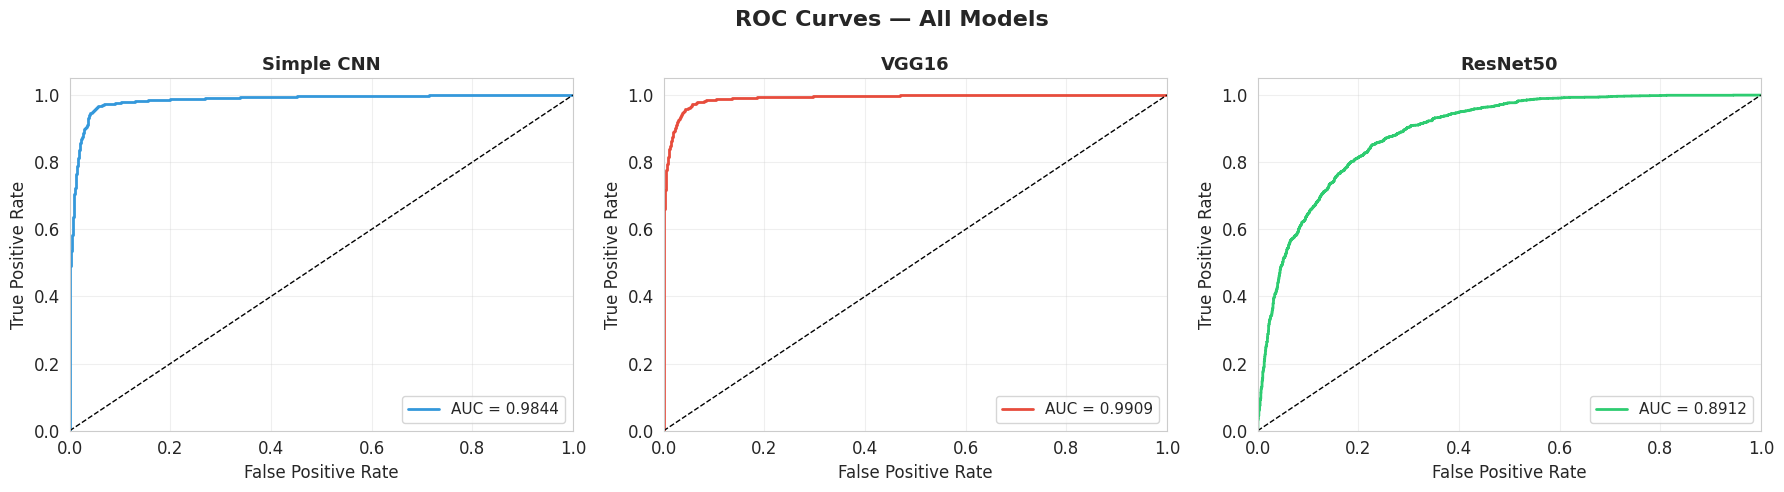

In [40]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves — All Models', fontsize=16, fontweight='bold')

for ax, (m_name, (y_t, y_p)), color in zip(axes, all_preds.items(), model_colors):
    fpr, tpr, _ = roc_curve(y_t, y_p)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.set_title(f'{m_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## **Best Model — Test Predictions**

In [41]:
res_reset = results_df.reset_index()
best_row = res_reset.loc[res_reset['Accuracy'].idxmax()]
best_model_name = best_row['Model']

print(f"Best Performing Model: {best_model_name}")
print(f"  Accuracy  : {best_row['Accuracy']:.4f}")
print(f"  Precision : {best_row['Precision']:.4f}")
print(f"  Recall    : {best_row['Recall']:.4f}")
print(f"  F1 Score  : {best_row['F1 Score']:.4f}")


Best Performing Model: VGG16
  Accuracy  : 0.9567
  Precision : 0.9415
  Recall    : 0.9739
  F1 Score  : 0.9574


In [42]:
model_paths = {
    'Simple CNN': 'model1_simple_cnn.keras',
    'VGG16':      'model2_vgg16.keras',
    'ResNet50':   'model3_resnet50.keras'
}
model_objs = {'Simple CNN': model1, 'VGG16': model2, 'ResNet50': model3}

try:
    best_model = load_model(model_paths[best_model_name])
    print(f"Loaded {best_model_name} from disk.")
except Exception as e:
    print(f"Using in-memory model. ({e})")
    best_model = model_objs[best_model_name]


Loaded VGG16 from disk.


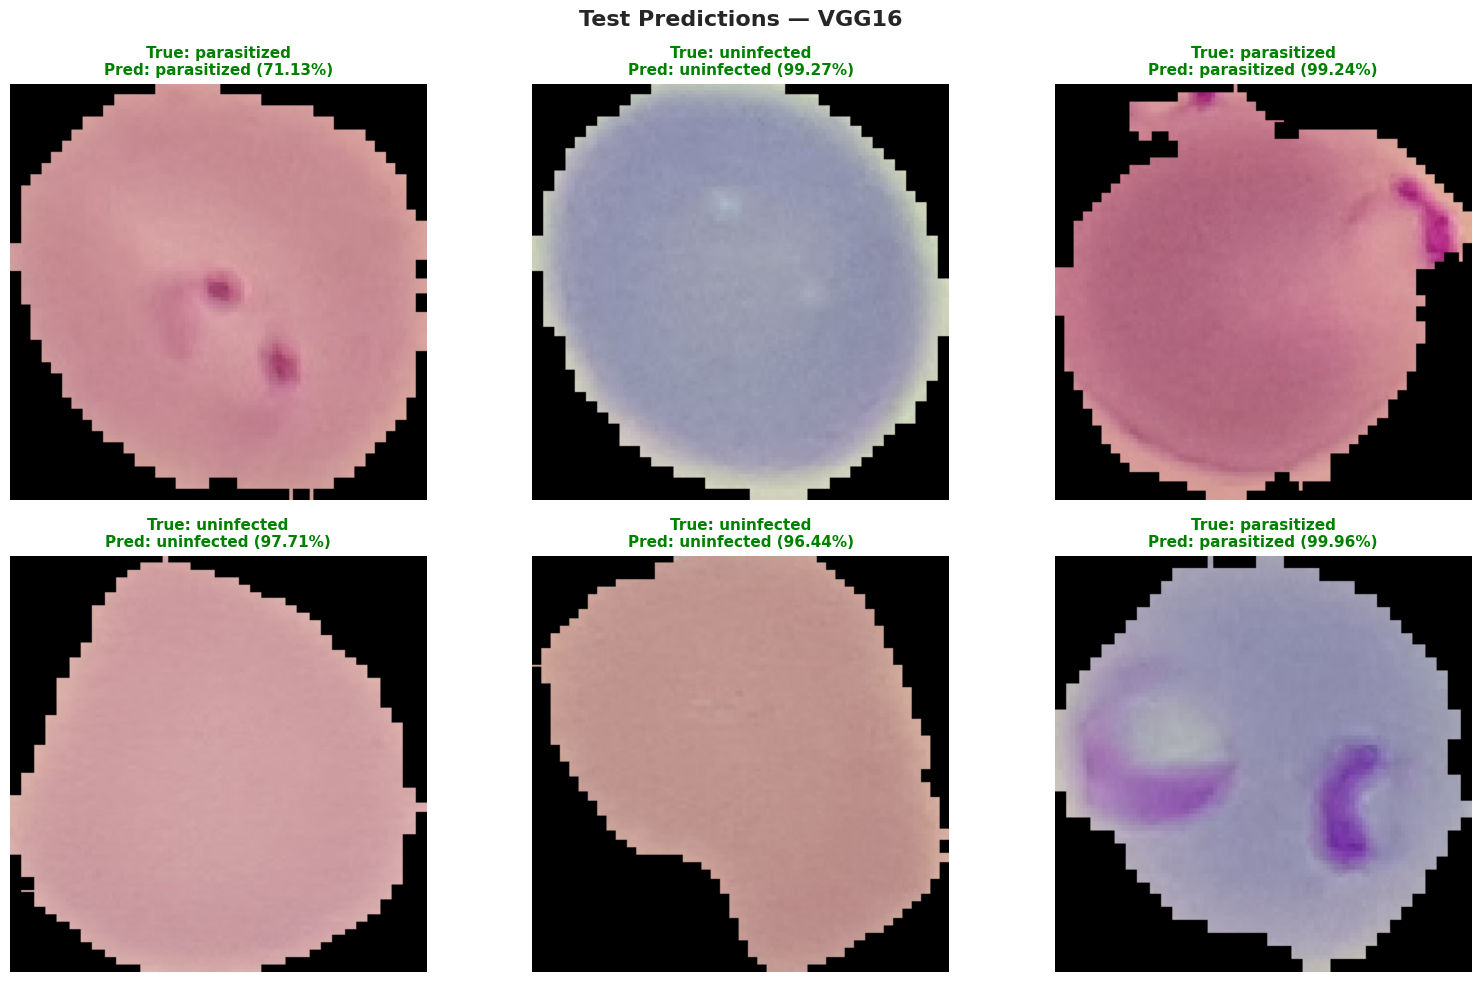

In [46]:
all_test_images = []
for class_folder in sorted(os.listdir(test_path)):
    class_path = os.path.join(test_path, class_folder)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_test_images.append((os.path.join(class_path, img_name), class_folder))

num_show = min(6, len(all_test_images))
selected = random.sample(all_test_images, num_show)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f'Test Predictions — {best_model_name}', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, (img_path, true_label) in enumerate(selected):
    img = load_img(img_path, target_size=IMG_SIZE)
    img_arr = img_to_array(img) / 255.0
    pred_prob = best_model.predict(np.expand_dims(img_arr, 0), verbose=0)[0][0]
    pred_label = 'uninfected' if pred_prob > 0.5 else 'parasitized'
    confidence  = pred_prob if pred_prob > 0.5 else 1 - pred_prob

    axes[idx].imshow(img)
    axes[idx].axis('off')
    color = 'green' if pred_label == true_label else 'red'
    axes[idx].set_title(
        f'True: {true_label}\nPred: {pred_label} ({confidence:.2%})',
        color=color, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## **Grad-CAM Visualization**

In [ ]:
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array)
        class_channel = preds[:, 0]
    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = last_conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def display_gradcam(image_path, heatmap, alpha=0.4):
    img = cv2.imread(image_path)
    img = cv2.resize(img, IMG_SIZE)
    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    jet = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img, 1 - alpha, jet, alpha, 0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    axes[2].set_title('Superimposed', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()


True label  : parasitized
Predicted   : parasitized  (confidence: 87.58%)


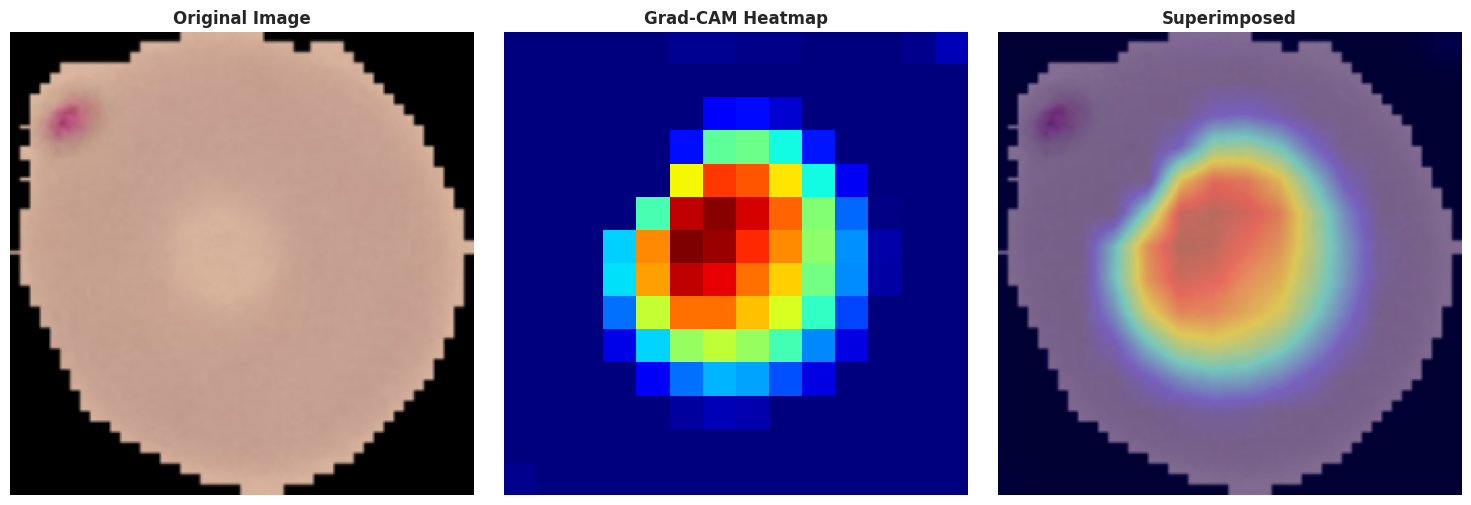

In [48]:
# Use VGG16 for Grad-CAM (last conv layer: block5_conv3)
try:
    model_gradcam = load_model('model2_vgg16.keras')
except Exception:
    model_gradcam = model2

last_conv = 'block5_conv3'

# Collect test images from both classes
all_test_gc = []
for cls_folder in ['parasitized', 'uninfected']:
    cls_path = os.path.join(test_path, cls_folder)
    if os.path.exists(cls_path):
        all_test_gc.extend(
            [(os.path.join(cls_path, f), cls_folder)
             for f in os.listdir(cls_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        )

if len(all_test_gc) == 0:
    print("No test images found.")
else:
    image_path, true_label = random.choice(all_test_gc)
    img = load_img(image_path, target_size=IMG_SIZE)
    img_arr = img_to_array(img) / 255.0
    img_input = np.expand_dims(img_arr, 0)

    pred_prob = model_gradcam.predict(img_input, verbose=0)[0][0]
    pred_label = 'uninfected' if pred_prob > 0.5 else 'parasitized'
    print(f"True label  : {true_label}")
    print(f"Predicted   : {pred_label}  (confidence: {max(pred_prob, 1-pred_prob):.2%})")

    heatmap = make_gradcam_heatmap(img_input, model_gradcam, last_conv)
    display_gradcam(image_path, heatmap)
